# Harker Diagrams

Harker diagrams are geochemical variation diagrams. They usually plot major oxides or trace elements against `SiO2` to show how a magma series changes during differentiation, mixing, alteration, or other petrogenetic processes.

In `geochem`, Harker diagrams are built from repeated bivariate scatter plots. This notebook shows:

1. high-level Harker diagrams with `harker()`;
2. selected-variable diagrams;
3. NumPy-style input;
4. low-level custom figures with `scatter()` and Matplotlib.

## Import Libraries and Load the Dataset

The Harker and scatter plotting tools are available from `geochem.plt`. The example dataset is loaded and preprocessed before plotting.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import geochem.plt as gc

In [2]:
DOCS_DIR = Path.cwd()
if not (DOCS_DIR / "data_example.csv").exists():
    DOCS_DIR = Path.cwd() / "docs"

csv_file = DOCS_DIR / "data_example.csv"
df = pd.read_csv(csv_file)

gc.preproc(df)
df.head()

Strip whitespaces from column names
>  column names before:
 ['Sample', 'Type', 'Description', 'Reference', 'Source', 'SiO2 ', 'Al2O3 ', 'TiO2 ', 'FeO', 'Fe2O3 ', 'FeOT', 'CaO ', 'MgO', 'MnO ', 'Na2O', 'K2O', 'P2O5', 'LOI', 'Sum', 'Cu', 'V', 'Cr', 'Co', 'Ni', 'Zn', 'Rb', 'Sr', 'Y', 'Zr', 'Nb', 'Ba', 'Pb', 'Sc', 'Ga', 'Cs', 'Hf', 'Ta', 'Th', 'U', 'La', 'Ce', 'Pr', 'Nd', 'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb', 'Lu']
>  column names after:
 ['Sample', 'Type', 'Description', 'Reference', 'Source', 'SiO2', 'Al2O3', 'TiO2', 'FeO', 'Fe2O3', 'FeOT', 'CaO', 'MgO', 'MnO', 'Na2O', 'K2O', 'P2O5', 'LOI', 'Sum', 'Cu', 'V', 'Cr', 'Co', 'Ni', 'Zn', 'Rb', 'Sr', 'Y', 'Zr', 'Nb', 'Ba', 'Pb', 'Sc', 'Ga', 'Cs', 'Hf', 'Ta', 'Th', 'U', 'La', 'Ce', 'Pr', 'Nd', 'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb', 'Lu']

Ensuring geochemical data columns are numeric
>  Processed/verified numeric columns: Cr (parsed)

Check columns with Fe oxides and calculate FeOT
.. FeO column in database
.. Fe2

,Sample,Type,Description,Reference,Source,SiO2,Al2O3,TiO2,FeO,Fe2O3,...,Sm,Eu,Gd,Tb,Dy,Ho,Er,Tm,Yb,Lu
0,HOR-06-01,Lava,Conos perifericos.,"Ruprecht, 2012",Hornitos,53.55,17.42,0.81,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CLHE1,Lava,Conos perifericos.,"Ruprecht, 2012",Hornitos,54.35,17.76,0.83,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CLHE2,Lava,Conos perifericos.,"Ruprecht, 2012",Hornitos,54.08,17.02,0.79,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CLHE-TF-04,Lava,Conos perifericos.,"Ruprecht, 2012",Hornitos,51.51,13.99,0.64,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CLHW1,Lava,Conos perifericos.,"Ruprecht, 2012",Hornitos,53.73,17.91,0.88,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## High-Level Harker Diagram

The high-level `harker()` function creates a grid of scatter plots. By default, it uses `SiO2` as the x-axis and plots the other major oxides recognized in the DataFrame.

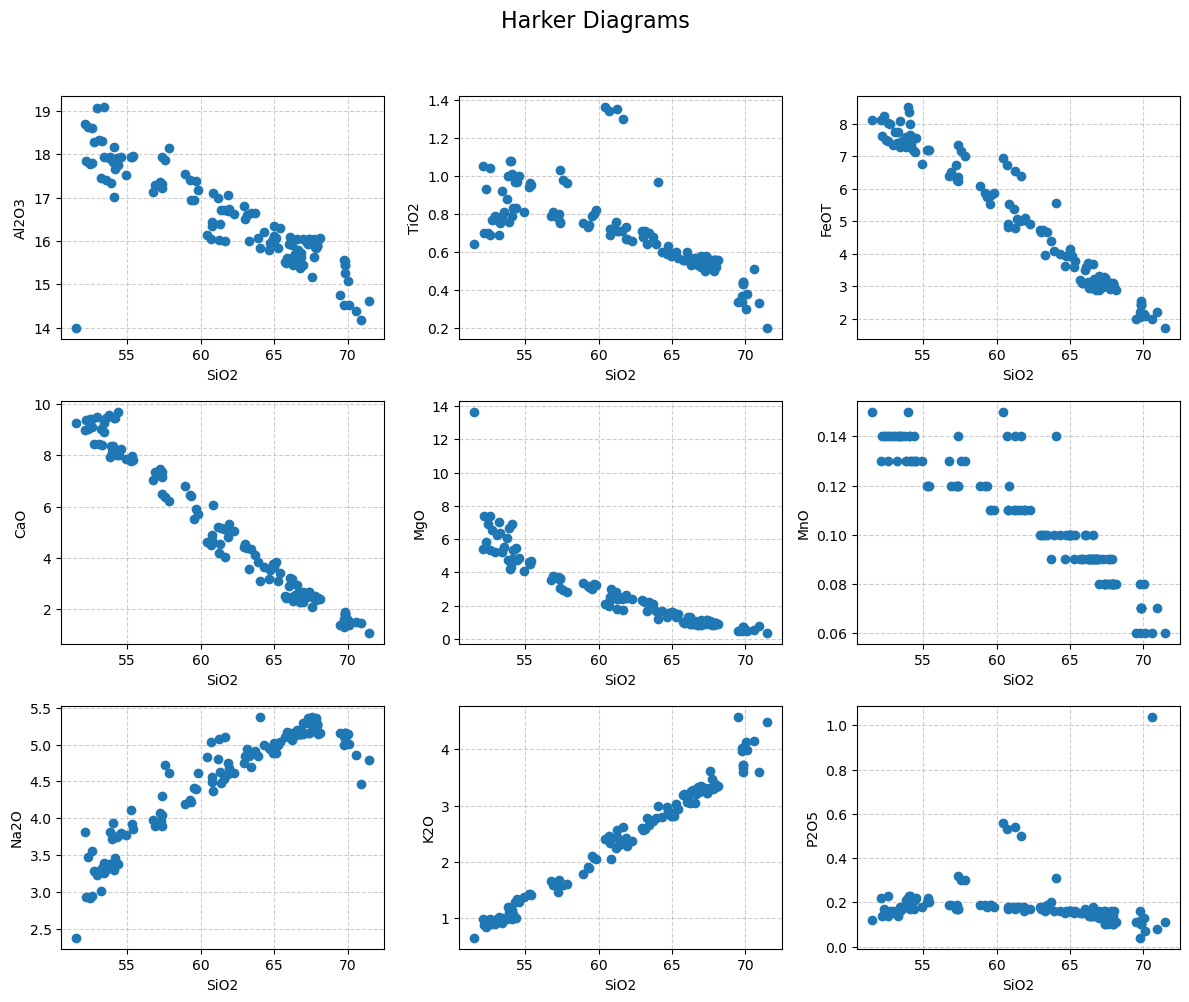

In [3]:
fig = gc.harker(df, fmt={"show": False})
plt.show()

You can use `fmt={"groupby": "Source"}` to color samples by a metadata column.

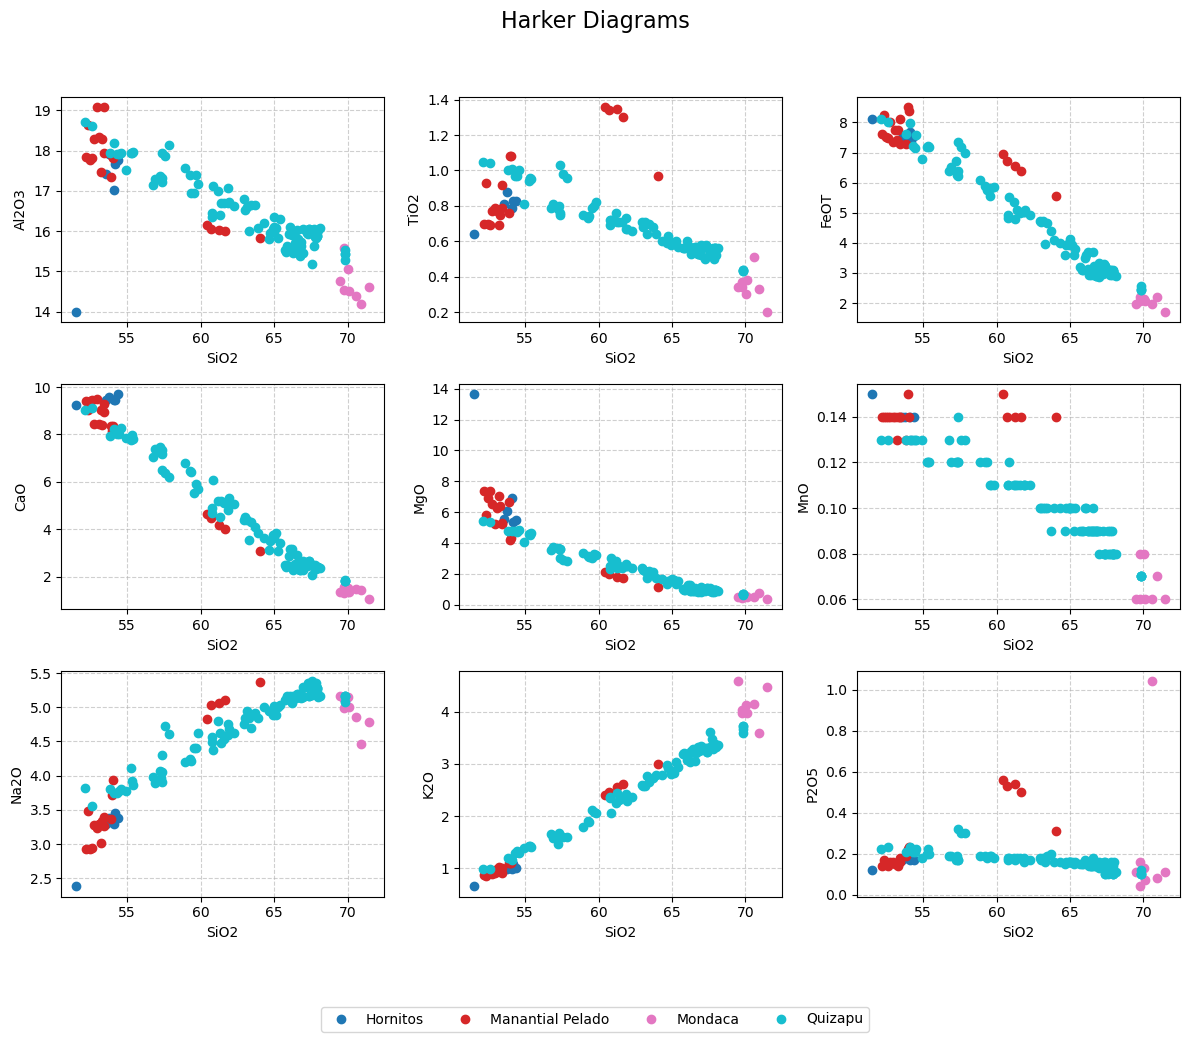

In [4]:
fig = gc.harker(df, fmt={"groupby": "Source", "show": False})
plt.show()

## Select Specific Variables

Use `y_cols` when you want to plot only selected oxides or elements against `SiO2`.

22 samples out of 129 removed due to missing values in 'SiO2' or 'Rb'.
6 samples out of 129 removed due to missing values in 'SiO2' or 'Sr'.


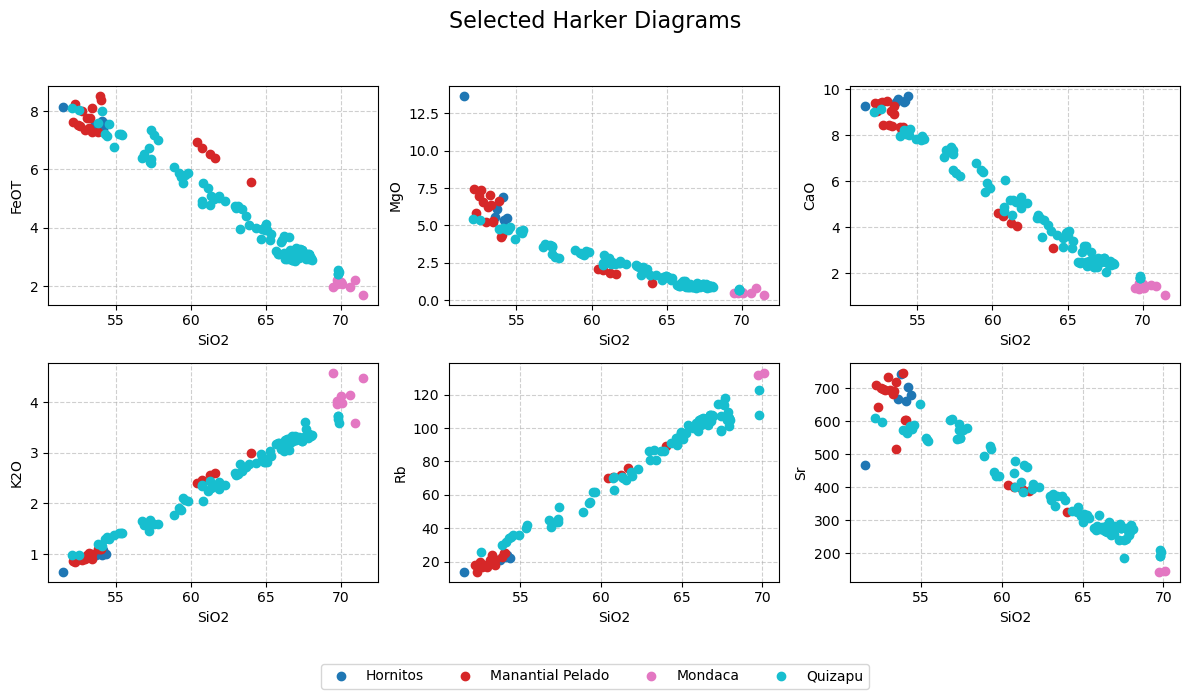

In [5]:
y_cols = ["FeOT", "MgO", "CaO", "K2O", "Rb", "Sr"]

fig = gc.harker(
    df,
    x_col="SiO2",
    y_cols=y_cols,
    fmt={"groupby": "Source", "title": "Selected Harker Diagrams", "show": False},
)
plt.show()

The x-axis does not have to be `SiO2`. Any numeric column can be used, although `SiO2` is the classical Harker-diagram choice.

22 samples out of 129 removed due to missing values in 'MgO' or 'Rb'.
6 samples out of 129 removed due to missing values in 'MgO' or 'Sr'.


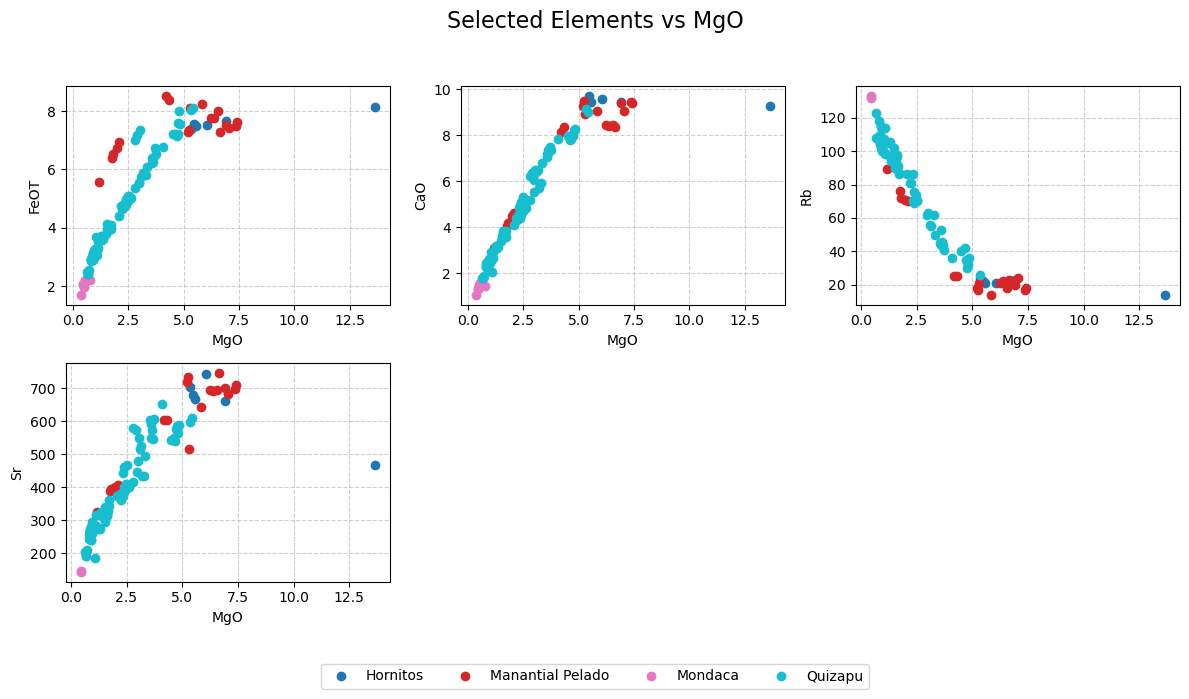

In [6]:
fig = gc.harker(
    df,
    x_col="MgO",
    y_cols=["FeOT", "CaO", "Rb", "Sr"],
    fmt={"groupby": "Source", "title": "Selected Elements vs MgO", "show": False},
)
plt.show()

## NumPy-Style Input

`harker()` also accepts a sequence of arrays: `[x_array, y_array_1, y_array_2, ...]`. In this mode, the y-axis labels are generated automatically as `Y1`, `Y2`, etc.

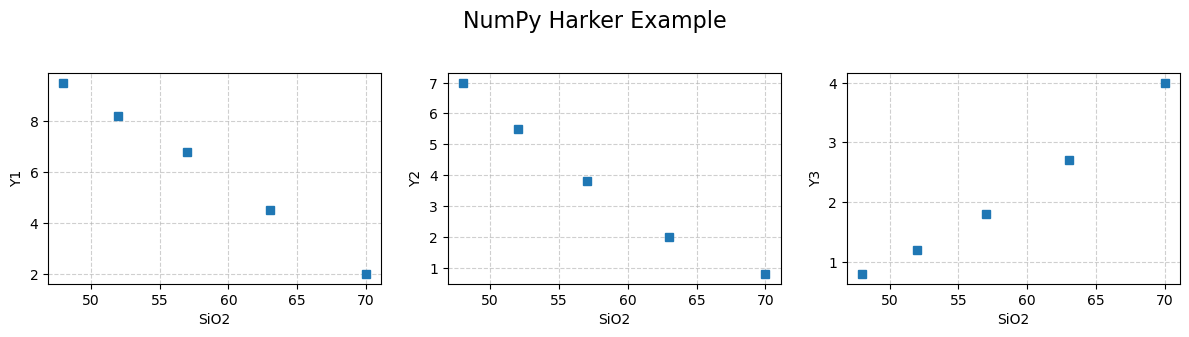

In [7]:
sio2 = np.array([48.0, 52.0, 57.0, 63.0, 70.0])
feo = np.array([9.5, 8.2, 6.8, 4.5, 2.0])
mgo = np.array([7.0, 5.5, 3.8, 2.0, 0.8])
k2o = np.array([0.8, 1.2, 1.8, 2.7, 4.0])

fig = gc.harker(
    [sio2, feo, mgo, k2o],
    x_col="SiO2",
    fmt={"title": "NumPy Harker Example", "marker": "s", "show": False},
)
plt.show()

## Low-Level Scatter Plot

The `harker()` function is a wrapper around repeated calls to `scatter()`. Use `scatter()` directly for a single bivariate diagram.

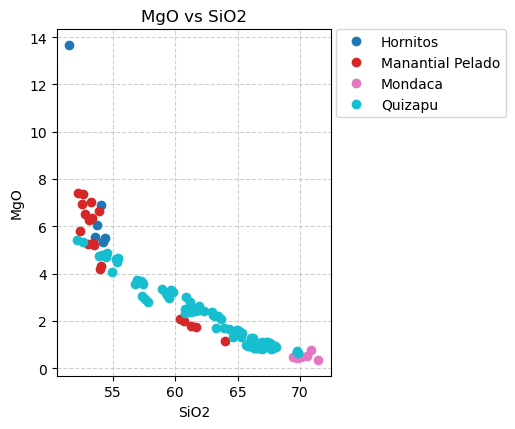

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
gc.scatter(
    df,
    x_col="SiO2",
    y_col="MgO",
    fmt={"groupby": "Source", "title": "MgO vs SiO2", "show": False},
    ax=ax,
)
plt.show()

`scatter()` also accepts two-array input.

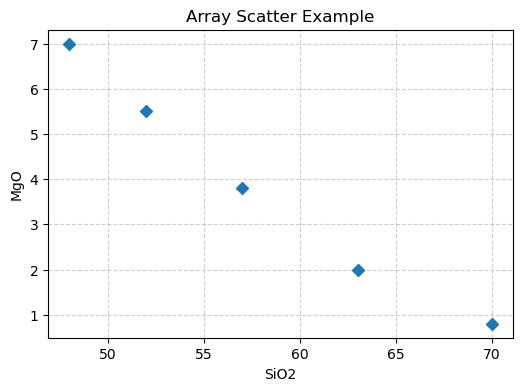

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
gc.scatter(
    [sio2, mgo],
    x_col="SiO2",
    y_col="MgO",
    fmt={"marker": "D", "title": "Array Scatter Example", "show": False},
    ax=ax,
)
plt.show()

## Build a Custom Harker Grid Manually

For full control over layout, axes, symbols, and legends, build the figure with Matplotlib and call `scatter()` on each axis.

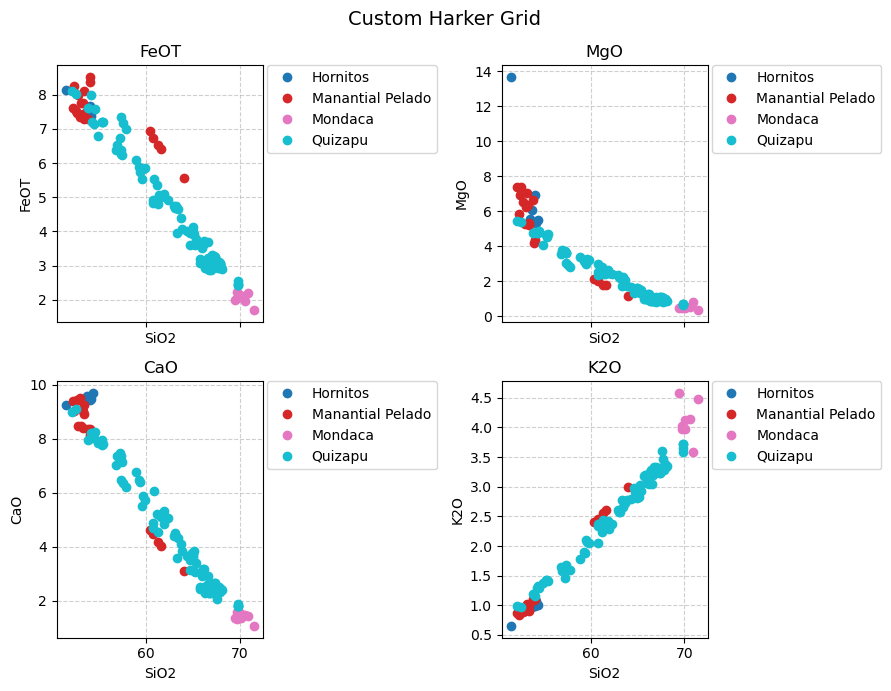

In [10]:
custom_y = ["FeOT", "MgO", "CaO", "K2O"]
fig, axes = plt.subplots(2, 2, figsize=(9, 7), sharex=True)
axes = axes.ravel()

for ax, y_col in zip(axes, custom_y):
    gc.scatter(
        df,
        x_col="SiO2",
        y_col=y_col,
        fmt={"groupby": "Source", "title": y_col, "show": False},
        ax=ax,
    )

fig.suptitle("Custom Harker Grid", fontsize=14)
fig.tight_layout()
plt.show()

## Summary

Use `gc.harker(df)` for quick Harker-diagram grids. Use `gc.scatter()` and Matplotlib when you need a single bivariate plot or a fully customized grid.